In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import yfinance as yf
from highlight_text import fig_text

# Get Data

In [5]:
START_YEAR = 2024

df = (
    yf.download(
        "GC=F",                 # gold ticker symbol
        period="5y",           # "1y", "5y", "max"
        interval="1d",          # "1d", "1wk", "1mo"
        auto_adjust=False,
    )
)

# apply a cut-off start date
df = df.loc[df.index >= pd.Timestamp(START_YEAR, 1, 1)]

# flatten columns to first level from MultiIndex
df.columns = df.columns.get_level_values(0)

# optional clean up and filtering
df = df[["Close"]]
df.columns.name = None 
df.index.name = None

# unit conversions (update values accordingly)
TOLA_GRAMS          = 11.664
TROY_OUNCE_GRAMS    = 31.1034768
USD_PER_NPR         = 0.0066     # 1 NPR = 0.0066 USD
NPR_PER_GBP         = 200.37     # 1 GBP = 200.10 NPR

# convert gold Close from USD/troy ounce to USD/tola
df["USD_per_tola"] = df["Close"] * (TOLA_GRAMS / TROY_OUNCE_GRAMS)

# USD -> NPR
df["NPR_per_tola"] = df["USD_per_tola"] / USD_PER_NPR

# NPR -> GBP
df["GBP_per_tola"] = df["NPR_per_tola"] / NPR_PER_GBP

[*********************100%***********************]  1 of 1 completed


In [6]:
df

,Close,USD_per_tola,NPR_per_tola,GBP_per_tola
2024-01-02,2064.399902,774.162986,117297.422055,585.404113
2024-01-03,2034.199951,762.837813,115581.486875,576.840280
2024-01-04,2042.300049,765.875401,116041.727438,579.137233
2024-01-05,2042.400024,765.912893,116047.407965,579.165583
2024-01-08,2026.599976,759.987775,115149.662817,574.685147
...,...,...,...,...
2026-03-16,4994.000000,1872.781502,283754.773036,1416.153980
2026-03-17,5001.000000,1875.406546,284152.506999,1418.138978
2026-03-18,4889.899902,1833.743309,277839.895266,1386.634203
2026-03-19,4600.700195,1725.291594,261407.817326,1304.625529


# Price of Gold Over Time

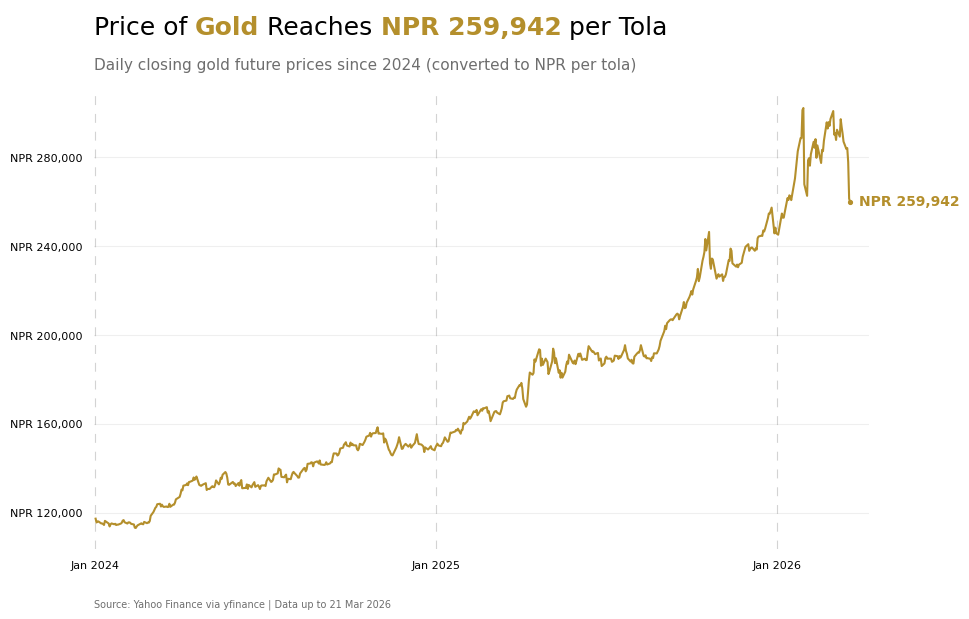

In [109]:
# colours
GOLD_COLOUR = "#B48F2CFF"
CURRENCY = "NPR"

y_values = df[f"{CURRENCY}_per_tola"]
currency = "£" if CURRENCY == "GBP" else "NPR "

# create figure
fig, ax = plt.subplots(figsize=(10, 6))

# axes formatting and display
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.grid(True, alpha=0.2, axis="y")
ax.tick_params(length=0, pad=8, labelsize=8)
# ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_locator(mdates.YearLocator())  # one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter(f"{currency}{{x:,.0f}}"))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
ax.set_xlim(df.index.min() - pd.Timedelta(days=2), df.index.max() + pd.Timedelta(days=20))

# add a vertical line for each year
for year in df.index.year.unique():
    year_start = pd.Timestamp(year, 1, 1)
    ax.axvline(
        x = year_start,
        linewidth=0.8,
        linestyle=(0, (8, 8)),
        color="#6e6e6e",
        alpha=0.3
    )

# line plot
ax.plot(
    df.index,
    y_values,
    linewidth=1.5,
    color=GOLD_COLOUR
)

# last data point marker
last_price = y_values.iloc[-1]
ax.scatter(
    df.index[-1],
    last_price,
    marker=".",
    s=30,
    color=GOLD_COLOUR,
)

# annotations on both sides
ax.text(
    x=df.index[-1] + pd.Timedelta(days=10),
    y=last_price,
    s=f"{currency}{y_values.iloc[-1]:,.0f}",
    ha="left",
    va="center",
    color=GOLD_COLOUR,
    fontsize=10,
    weight="bold"
)

# title
x_value, y_value = 0.125, 1
fig_text(
    x=x_value,
    y=y_value,
    s=f"Price of <Gold> Reaches <{currency}{last_price:,.0f}> per Tola",
    highlight_textprops=[
        {"color": GOLD_COLOUR, "weight": "bold"},
        {"color": GOLD_COLOUR, "weight": "bold"}
    ],
    size=18
)

# subtitle
fig.text(
    x=x_value,
    y=y_value * 0.91,
    s=f"Daily closing gold future prices since {START_YEAR} (converted to {CURRENCY} per tola)",
    size=11,
    color="#6e6e6e"
)

# caption
today_fmt = pd.Timestamp.today().strftime("%d %b %Y")
fig.text(
    x_value,
    0.01,
    s=(
        f"Source: Yahoo Finance via yfinance"
        f" | Data up to {today_fmt}"
    ),
    ha="left",
    va="bottom",
    fontsize=7,
    color="#6e6e6e",
)

plt.savefig("../images/gold_price_per_tola.svg", bbox_inches="tight")

plt.show()